###### Content under Creative Commons Attribution license CC-BY 4.0, code under BSD 3-Clause License © 2022 by D. Koehn, notebook style sheet by L.A. Barba, N.C. Clementi

# Digital Signal Processing: Mathematical Foundations

## Exercise 3.2  

Define a sine function with a period of 25 s and calculate its spectrum. Plot the amplitude spectrum, the real part and the imaginary part graphically in a suitable positive frequency domain. The sampling interval should be 0.1 s. The number of values must be chosen such that exactly one integer multiple of the period is represented within the observation interval. Also ensure that the sine function is a power signal and that you normalize the spectrum accordingly. Do you want to plot twice the value of the amplitude spectrum? Why? The length of the observation interval should take the following values in sequence:

- 50 s,
- 100 s,
- 1000 s,
- 10000 s.

Interpret the results. How does the sampling step change in the frequency domain?

In [1]:
# Import Libraries
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

We begin by defining the period of the sine function and the sampling interval.

In [2]:
# Define parameters
T = 25.                  # period
dt = .1                  # time sampling

Since the assignment requires us to generate time series of varying lengths, it makes sense to define them generally within a function and then simply vary the input parameters.

In [3]:
def def_sine(T,dt,L):
    
    omega = 2. * np.pi / T   # compute circular frequency from period
    t = np.arange(0,L+dt,dt) # compute time vector
    x = np.sin(omega*t)      # compute sine wave
    
    return t,x

Using the `def_sine` function, we can easily generate the desired time series.

In [4]:
t_25, x_25 = def_sine(T,dt,25)
t_50, x_50 = def_sine(T,dt,50)
t_100, x_100 = def_sine(T,dt,100)
t_1000, x_1000 = def_sine(T,dt,1000)
t_10000, x_10000 = def_sine(T,dt,10000)

Using the `Numpy` function [fft.fft](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html), we can compute the Fourier transform, and using the function [fft.fftfreq](https://numpy.org/doc/stable/reference/generated/numpy.fft.fftfreq.html), we can compute the corresponding frequencies. Since the sine function is a power signal, we normalize the Fourier-transformed time series to the length of the observation interval $L = N dt$, where $N$ denotes the number of time samples and $dt$ denotes the sample interval. We summarize all steps in the function `x_fft` ...

In [5]:
def x_fft(x,dt):
    
    # Fourier transform
    X = np.fft.fft(x)
    
    # Normalize by length of the time series
    N = len(x)
    X = X / (N*dt)
    
    # estimate frequencies    
    freq = np.fft.fftfreq(N, d=dt)
    
    # swap positive and negative parts of the FFT / frequencies using fftshift for 
    # correct amplitude spectrum plot of negative and positive frequencies
    X = np.fft.fftshift(X)
    freq = np.fft.fftshift(freq)
    
    return freq,X

... and apply them to the time series.

In [6]:
# Compute FFT and frequencies
freq_25, X_25 = x_fft(x_25,dt)
freq_50, X_50 = x_fft(x_50,dt)
freq_100, X_100 = x_fft(x_100,dt)
freq_1000, X_1000 = x_fft(x_1000,dt)
freq_10000, X_10000 = x_fft(x_10000,dt)

Next, we plot the amplitude spectra ...

(0.0, 0.15)

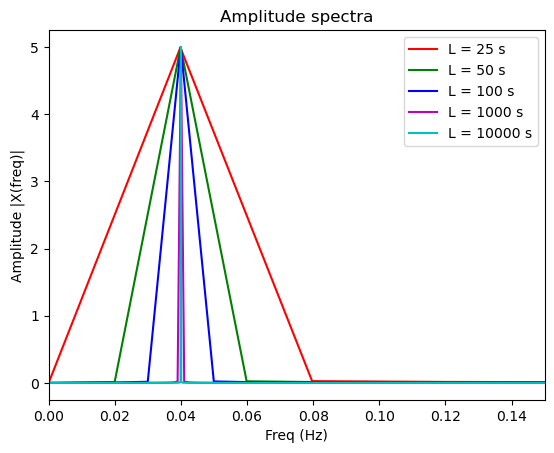

In [7]:
plt.plot(freq_25, np.abs(X_25), 'r', label='L = 25 s')
plt.plot(freq_50, np.abs(X_50), 'g', label='L = 50 s')
plt.plot(freq_100, np.abs(X_100), 'b', label='L = 100 s')
plt.plot(freq_1000, np.abs(X_1000), 'm', label='L = 1000 s')
plt.plot(freq_10000, np.abs(X_10000), 'c', label='L = 10000 s')
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude |X(freq)|')
plt.title('Amplitude spectra')
plt.legend()
plt.xlim(0, 0.15)

It is very clear that extending the time series results in a higher-resolution amplitude spectrum.

If we remove the normalization of the Fourier transform to the length of the observation interval, we also see that the amplitude of the peak increases as the length of the observation interval increases. In the extreme case of an infinitely long time series, we obtain the Dirac $\delta$-pulse.

One could multiply the amplitude spectrum by a factor of 2 to add the energy present in the second peak at -0.04 Hz to this peak at 0.4 Hz. This would illustrate the total energy of the time series, but would ignore the fact that the total energy is distributed between the positive and negative peaks. 

Finally, we plot the real...

(0.0, 0.15)

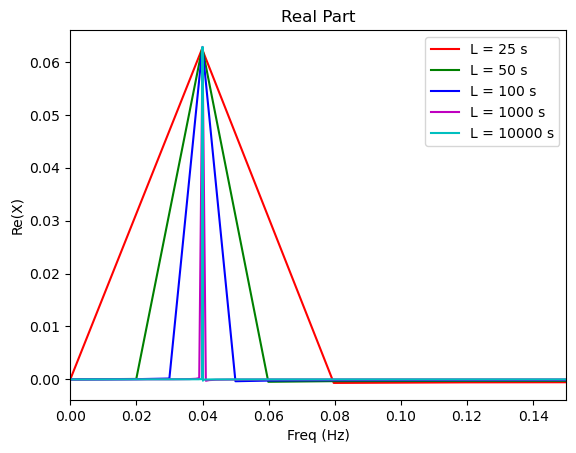

In [8]:
plt.plot(freq_25, np.real(X_25), 'r', label='L = 25 s')
plt.plot(freq_50, np.real(X_50), 'g', label='L = 50 s')
plt.plot(freq_100, np.real(X_100), 'b', label='L = 100 s')
plt.plot(freq_1000, np.real(X_1000), 'm', label='L = 1000 s')
plt.plot(freq_10000, np.real(X_10000), 'c', label='L = 10000 s')
plt.xlabel('Freq (Hz)')
plt.ylabel('Re(X)')
plt.title('Real Part')
plt.legend()
plt.xlim(0., 0.15)

... and imaginary parts ...

(0.0, 0.15)

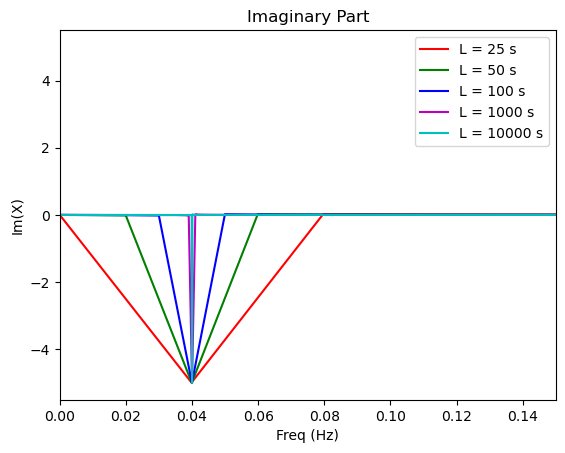

In [9]:
plt.plot(freq_25, np.imag(X_25), 'r', label='L = 25 s')
plt.plot(freq_50, np.imag(X_50), 'g', label='L = 50 s')
plt.plot(freq_100, np.imag(X_100), 'b', label='L = 100 s')
plt.plot(freq_1000, np.imag(X_1000), 'm', label='L = 1000 s')
plt.plot(freq_10000, np.imag(X_10000), 'c', label='L = 10000 s')
plt.xlabel('Freq (Hz)')
plt.ylabel('Im(X)')
plt.title('Imaginary Part')
plt.legend()
plt.xlim(0., 0.15)

Why does the numerical FFT of the sine function actually have a real part? For the continuous sine function, the real part is zero.

## Exercise 3.2  

Change the period of the sine function to 22 s and repeat the calculations from the previous exercise for the observation interval lengths specified there, which are no longer integer multiples of the period. Interpret the results.

In [10]:
# Define parameters
T1 = 22.                 # new period
dt = .1                  # time sampling

Definition of the new time series ...

In [11]:
t_25, x_25 = def_sine(T1,dt,25)
t_50, x_50 = def_sine(T1,dt,50)
t_100, x_100 = def_sine(T1,dt,100)
t_1000, x_1000 = def_sine(T1,dt,1000)
t_10000, x_10000 = def_sine(T1,dt,10000)

... and their Fourier transforms and amplitude spectra.

(0.0, 0.15)

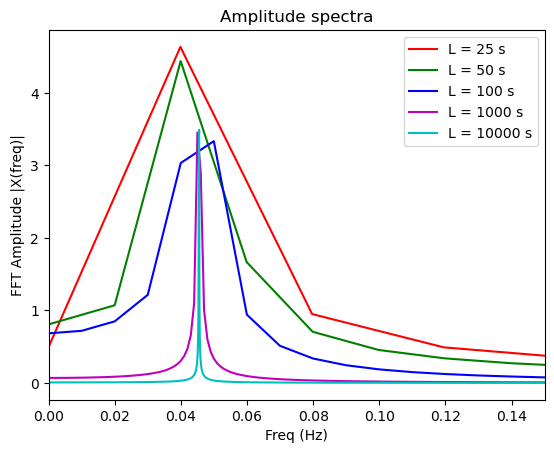

In [12]:
# Compute FFT and frequencies
freq_25, X_25 = x_fft(x_25,dt)
freq_50, X_50 = x_fft(x_50,dt)
freq_100, X_100 = x_fft(x_100,dt)
freq_1000, X_1000 = x_fft(x_1000,dt)
freq_10000, X_10000 = x_fft(x_10000,dt)

plt.plot(freq_25, np.abs(X_25), 'r', label='L = 25 s')
plt.plot(freq_50, np.abs(X_50), 'g', label='L = 50 s')
plt.plot(freq_100, np.abs(X_100), 'b', label='L = 100 s')
plt.plot(freq_1000, np.abs(X_1000), 'm', label='L = 1000 s')
plt.plot(freq_10000, np.abs(X_10000), 'c', label='L = 10000 s')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.title('Amplitude spectra')
plt.legend()
plt.xlim(0, .15)

Compared to the amplitude spectra of the sine wave at T = 25 s, a significant shift of the peak maximum to $\frac{1}{22\; s} = 0.045 Hz$ can be observed at T = 22 s for long time series. For shorter time series, which sample the sine function over only a few periods, the peak of the spectral line appears at an incorrect frequency. Furthermore, the lines appear wider. We can attribute this behavior to the [leakage effect](https://de.wikipedia.org/wiki/Leck-Effekt#Zeitdiskrete_Systeme) for a non-periodic signal.

## Problem 3.3 

Define a two-dimensional array $\cos(k_x x)\cos(k_y y)$ with $k_x = 2\pi/(50 \text{m})$ and $k_y = 0$. The interval should be $(0,200 \text{m})$ in both the x- and y-directions. The sampling step should be 1 m in both the x- and y-directions. Plot the amplitude spectrum of the two-dimensional Fourier transform in the two-dimensional interval $-0.1 \text{m} \leq k_x \leq 0.1 \text{m}$ and $-0.1 \text{m} \leq k_y \leq 0.1 \text{m}$. Interpret the results.

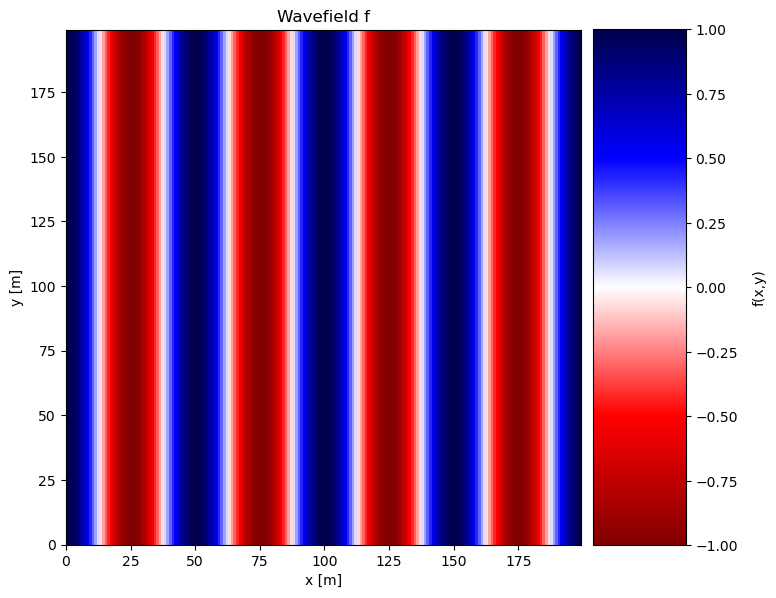

In [13]:
# Definitions
dh = 1. # spatial sampling
xmax = 200.  # maximum x-coordinate in x-direction
ymax = 200.  # maximum y-coordinate in y-direction

# Wavenumbers in x- and y-direction
kx = 2. * np.pi / 50.
ky = 0.

# 2D coordinates
X, Y = np.meshgrid(np.arange(0, xmax, dh), np.arange(0, ymax, dh))

# Compute two-dimensional wavefield
f = np.cos(kx*X)*np.cos(ky*Y)

# Define image size
plt.figure(figsize=(8,8))

# Plot of wavefield f
image = plt.imshow(f, cmap=plt.cm.seismic_r, interpolation='nearest', 
                   extent=[np.min(X),np.max(X),np.min(Y),np.max(Y)],aspect=1)

cbar = plt.colorbar(aspect=5.55, pad=0.02)
cbar.set_label('f(x,y)', labelpad=10)
plt.title('Wavefield f')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

Compute the 2D Fourier transform of the wavefield f(x,y) using the `NumPy` function [fft2](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft2.html) and shift the origin to the center of the 2D spectrum using [fftshift](https://numpy.org/doc/stable/reference/generated/numpy.fft.fftshift.html)

In [14]:
# 2D FFT
F = np.fft.fft2(f)

# Normalize 2D FFT
Nx, Ny = np.shape(F)
F = F / (dh*Nx)

# Shift zero-frequency to the center of the 2D spectrum
F = np.fft.fftshift(F, axes=None)

Calculate the circular wavenumbers KX and KY

In [15]:
# Compute wavenumbers in x- and y-direction
KX = np.arange(-Nx//2, Nx//2, 1)
KY = np.arange(-Ny//2, Ny//2, 1)

KX = 2. * np.pi * KX / (dh*Nx)
KY = 2. * np.pi * KY / (dh*Ny)

Plot 2D amplitude spectrum

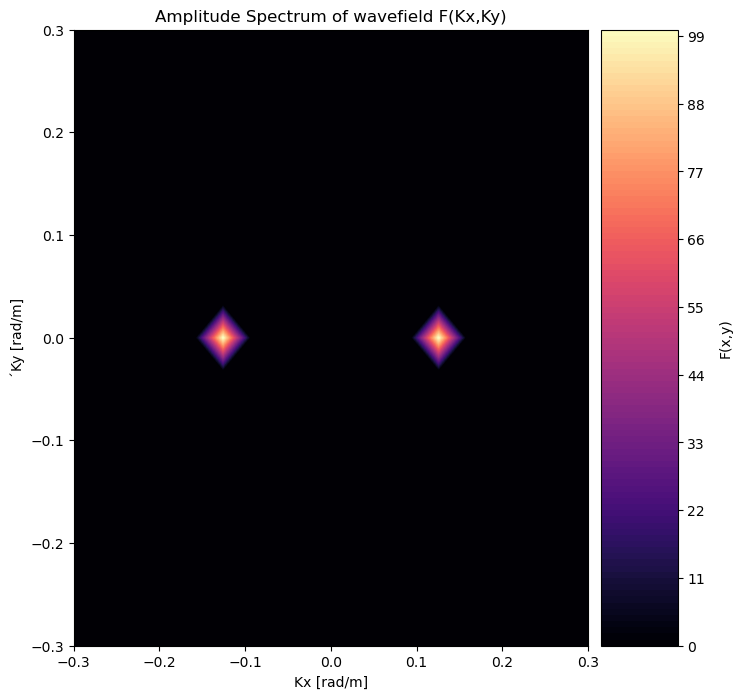

In [16]:
# Plot 2D amplitude spectrum

# Image size
plt.figure(figsize=(8,8))

# Plot amplitude spectrum
levels = np.linspace(np.min(np.abs(F)), np.max(np.abs(F)), num=101)
plt.contourf(KX, KY, np.abs(F),levels=levels,cmap='magma')

cbar = plt.colorbar(aspect=8, pad=0.02)
cbar.set_label('F(x,y)', labelpad=10)
plt.title('Amplitude Spectrum of wavefield F(Kx,Ky)')
plt.xlabel('Kx [rad/m]')
plt.ylabel('´Ky [rad/m]')
xylim = .3
plt.xlim([-xylim,xylim])
plt.ylim([-xylim,xylim])
plt.show()

In the amplitude spectrum, there should theoretically be two maxima at circular wavenumbers $(Kx_1,Ky_1)$ = $(\frac{2\pi}{50},0)\; rad/m$ and $(Kx_2,Ky_2)$ = $(-\frac{2\pi}{50},0)\; rad/m$.

In [17]:
Kx1 = 2. * np.pi / 50
Kx2 = -2. * np.pi / 50
print('Kx1 = ', Kx1, 'rad/m')
print('Kx2 = ', Kx2, 'rad/m')

Kx1 =  0.12566370614359174 rad/m
Kx2 =  -0.12566370614359174 rad/m


We can verify this by using the `NumPy` function `where` to determine at which indices the normalized amplitude spectrum takes on a value of 99 or greater ...

In [18]:
out = np.where(np.abs(F)>=99)
print(out)

(array([100, 100]), array([ 96, 104]))


... and determine the corresponding wavenumber for these indices:

In [19]:
KX[96]

np.float64(-0.12566370614359174)

In [20]:
KX[104]

np.float64(0.12566370614359174)